In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor, VotingRegressor

from scipy import stats
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Preprocessing
[House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview)

In [4]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [5]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
for df in [train_df, test_df]:
  df.drop(["Alley", "PoolQC", "Fence", "MiscFeature", "Id"], axis=1, inplace=True)

##EDA

### Outliers

In [8]:
train_df.dtypes[train_df.dtypes != "object"]

,0
Id,int64
MSSubClass,int64
LotFrontage,float64
LotArea,int64
OverallQual,int64
OverallCond,int64
YearBuilt,int64
YearRemodAdd,int64
MasVnrArea,float64
BsmtFinSF1,int64


<Axes: xlabel='MSSubClass', ylabel='SalePrice'>

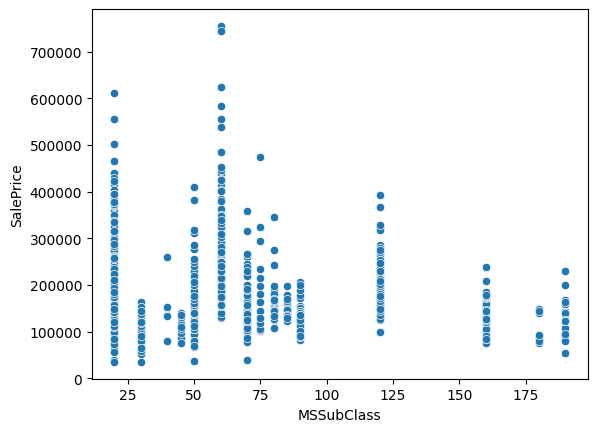

In [9]:
sns.scatterplot(x="MSSubClass", y="SalePrice", data=train_df)

<Axes: xlabel='LotFrontage', ylabel='SalePrice'>

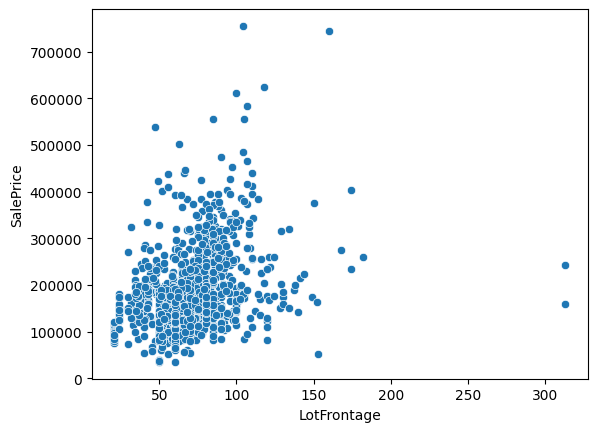

In [10]:
sns.scatterplot(x="LotFrontage", y="SalePrice", data=train_df)

In [11]:
train_df.query("LotFrontage > 250")
#934, 1298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,IR2,HLS,AllPub,Inside,...,0,0,0,0,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


<Axes: xlabel='LotArea', ylabel='SalePrice'>

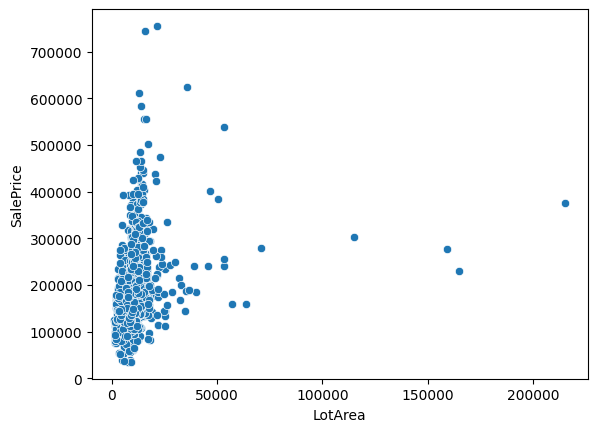

In [12]:
sns.scatterplot(x="LotArea", y="SalePrice", data=train_df)

In [13]:
train_df.query("LotArea > 100000")
#249, 313, 335, 706

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,IR2,Low,AllPub,CulDSac,...,0,0,0,0,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,IR3,Low,AllPub,Inside,...,0,0,0,0,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,IR1,HLS,AllPub,Corner,...,0,0,0,0,700,8,2008,WD,Normal,228950
706,707,20,RL,NaN,115149,Pave,IR2,Low,AllPub,CulDSac,...,0,0,0,0,0,6,2007,WD,Normal,302000


<Axes: xlabel='OverallQual', ylabel='SalePrice'>

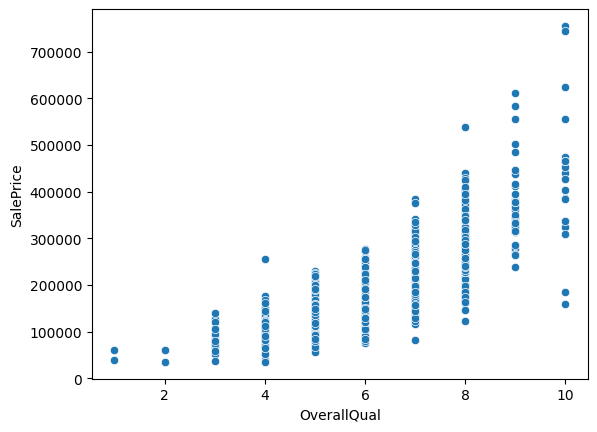

In [14]:
sns.scatterplot(x="OverallQual", y="SalePrice", data=train_df)

In [15]:
train_df.query("OverallQual == 10 and SalePrice < 300000")
# 523, 1298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,...,0,0,0,0,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


<Axes: xlabel='OverallCond', ylabel='SalePrice'>

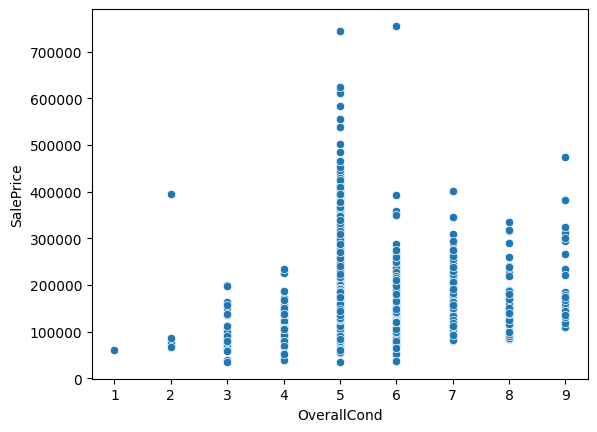

In [16]:
sns.scatterplot(x="OverallCond", y="SalePrice", data=train_df)

In [17]:
train_df.query("OverallCond == 2 and SalePrice > 300000")
#378

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
378,379,20,RL,88.0,11394,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,6,2010,New,Partial,394432


In [18]:
train_df.query("(OverallCond == 5 or OverallCond == 6) and SalePrice > 650000")
# 691, 1182

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

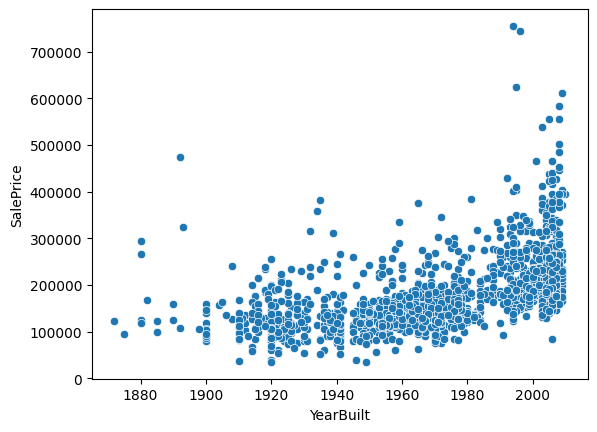

In [19]:
sns.scatterplot(x="YearBuilt", y="SalePrice", data=train_df)

In [20]:
train_df.query("YearBuilt < 1900 & SalePrice > 400000")
#185

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,IR2,Lvl,AllPub,Inside,...,0,0,410,0,0,6,2006,WD,Normal,475000


<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

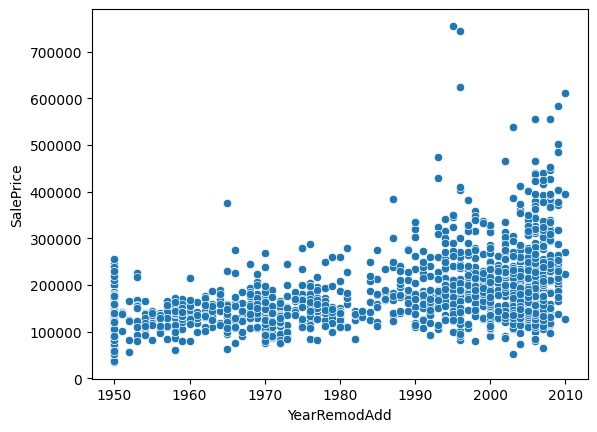

In [21]:
sns.scatterplot(x="YearRemodAdd", y="SalePrice", data=train_df)

In [22]:
train_df.query("YearRemodAdd < 1970 & SalePrice > 300000")
#313

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
313,314,20,RL,150.0,215245,Pave,IR3,Low,AllPub,Inside,...,0,0,0,0,0,6,2009,WD,Normal,375000


<Axes: xlabel='MasVnrArea', ylabel='SalePrice'>

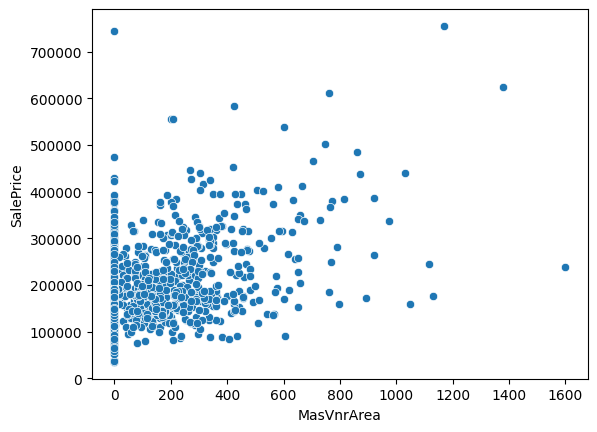

In [23]:
sns.scatterplot(x="MasVnrArea", y="SalePrice", data=train_df)

In [24]:
train_df.query("MasVnrArea == 0 & SalePrice > 700000")
#1182

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


In [25]:
train_df.query("MasVnrArea > 1400")
#297

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,IR1,Lvl,AllPub,Inside,...,0,0,198,0,0,6,2007,WD,Normal,239000


<Axes: xlabel='BsmtFinSF1', ylabel='SalePrice'>

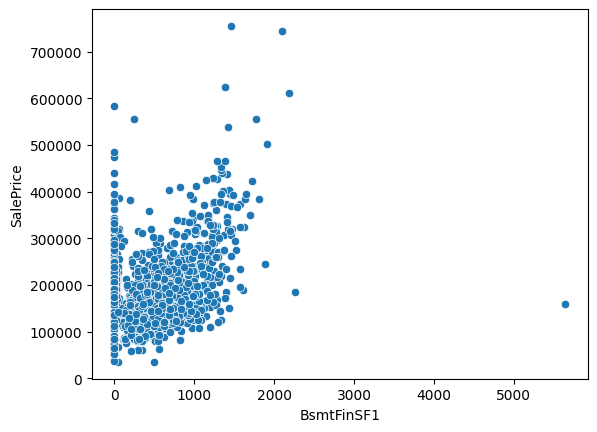

In [26]:
sns.scatterplot(x="BsmtFinSF1", y="SalePrice", data=train_df)

In [27]:
train_df.query("BsmtFinSF1 > 5000")
#1298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


<Axes: xlabel='BsmtFinSF2', ylabel='SalePrice'>

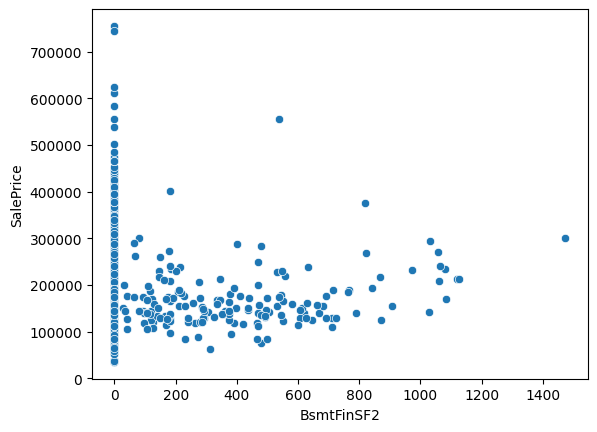

In [28]:
sns.scatterplot(x="BsmtFinSF2", y="SalePrice", data=train_df)

In [29]:
train_df.query("BsmtFinSF2 > 400 & SalePrice > 500000")
#440

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,Reg,Lvl,AllPub,Inside,...,0,0,170,0,0,4,2009,WD,Normal,555000


<Axes: xlabel='BsmtUnfSF', ylabel='SalePrice'>

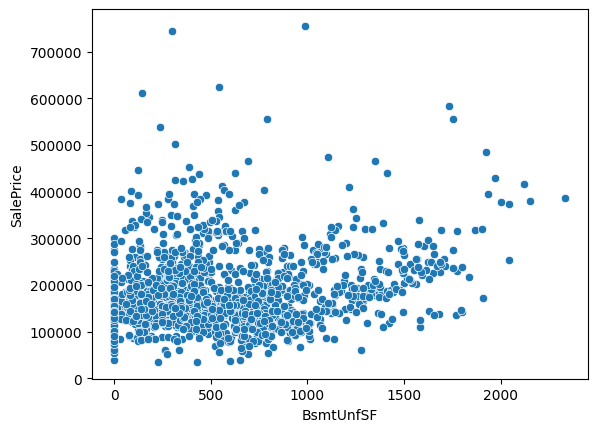

In [30]:
sns.scatterplot(x="BsmtUnfSF", y="SalePrice", data=train_df)

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

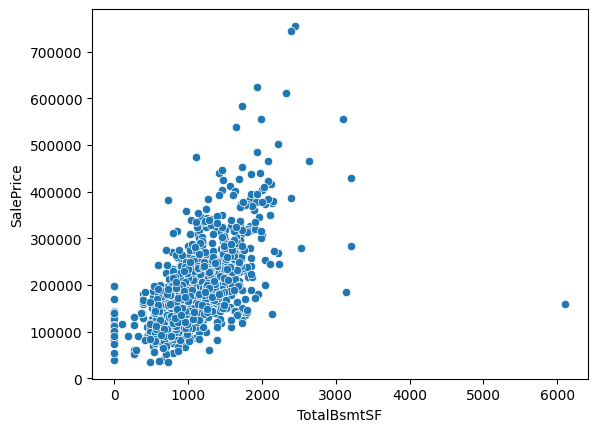

In [31]:
sns.scatterplot(x="TotalBsmtSF", y="SalePrice", data=train_df)

In [32]:
train_df.query("TotalBsmtSF > 5000")
#1298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


<Axes: xlabel='1stFlrSF', ylabel='SalePrice'>

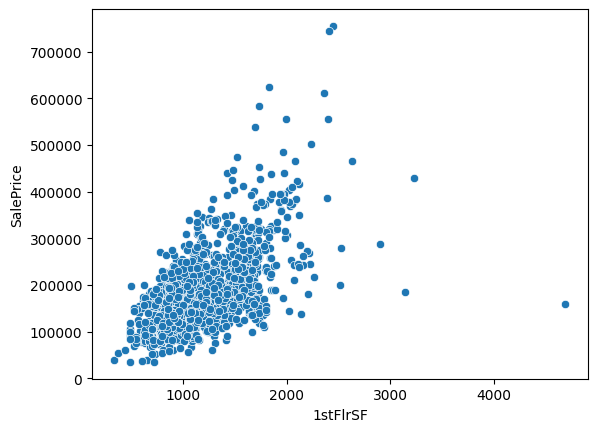

In [33]:
sns.scatterplot(x="1stFlrSF", y="SalePrice", data=train_df)

<Axes: xlabel='2ndFlrSF', ylabel='SalePrice'>

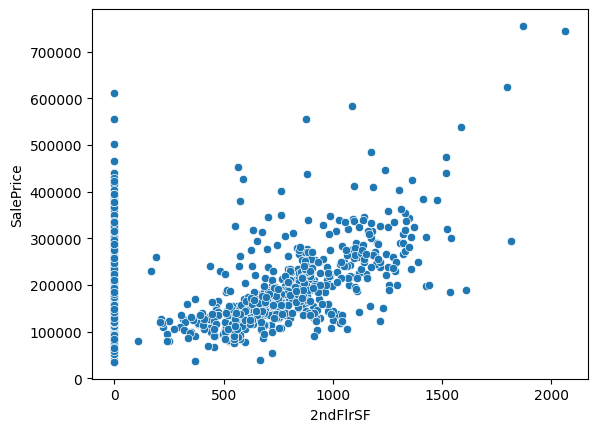

In [34]:
sns.scatterplot(x="2ndFlrSF", y="SalePrice", data=train_df)

<Axes: xlabel='LowQualFinSF', ylabel='SalePrice'>

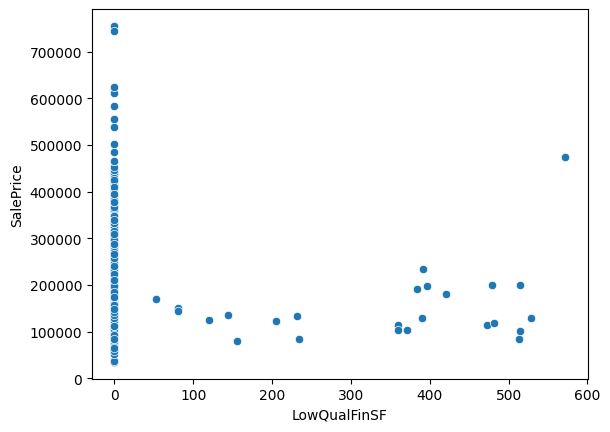

In [35]:
sns.scatterplot(x="LowQualFinSF", y="SalePrice", data=train_df)

In [36]:
train_df.query("LowQualFinSF > 550")
#185

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,IR2,Lvl,AllPub,Inside,...,0,0,410,0,0,6,2006,WD,Normal,475000


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

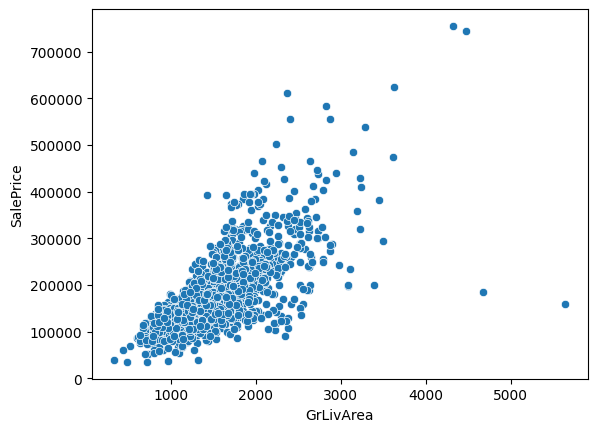

In [37]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=train_df)

In [38]:
train_df.query("GrLivArea > 4000 & SalePrice < 300000")
#523, 1298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,...,0,0,0,0,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


<Axes: xlabel='BsmtFullBath', ylabel='SalePrice'>

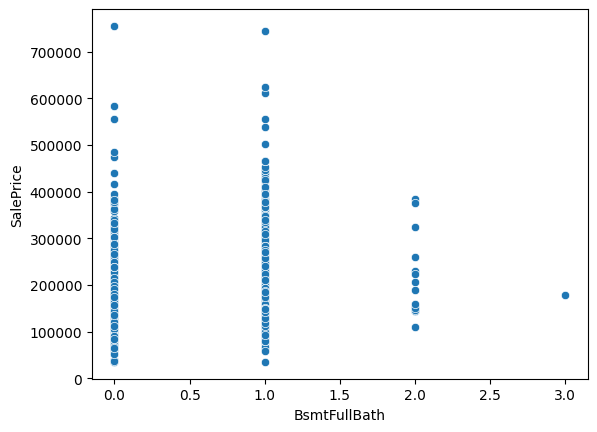

In [39]:
sns.scatterplot(x="BsmtFullBath", y="SalePrice", data=train_df)

In [40]:
train_df.query("BsmtFullBath == 3")
#738

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,3,2009,WD,Alloca,179000


<Axes: xlabel='BsmtHalfBath', ylabel='SalePrice'>

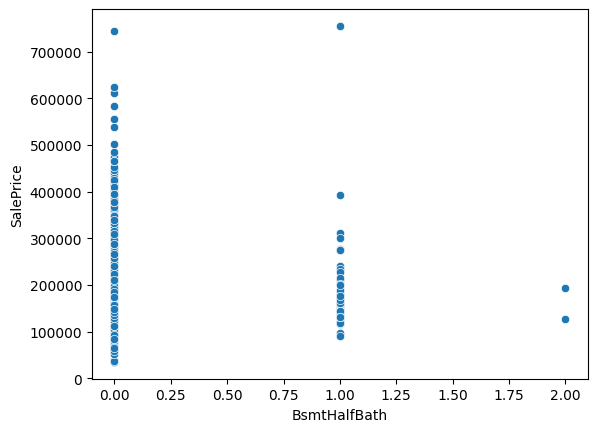

In [41]:
sns.scatterplot(x="BsmtHalfBath", y="SalePrice", data=train_df)

In [42]:
train_df.query("BsmtHalfBath == 2")
#597, 954

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,IR1,Lvl,AllPub,CulDSac,...,0,0,0,0,0,10,2006,WD,AdjLand,127500


<Axes: xlabel='FullBath', ylabel='SalePrice'>

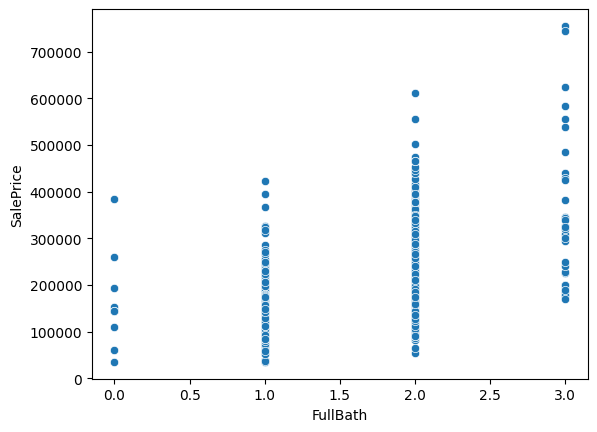

In [43]:
sns.scatterplot(x="FullBath", y="SalePrice", data=train_df)

<Axes: xlabel='HalfBath', ylabel='SalePrice'>

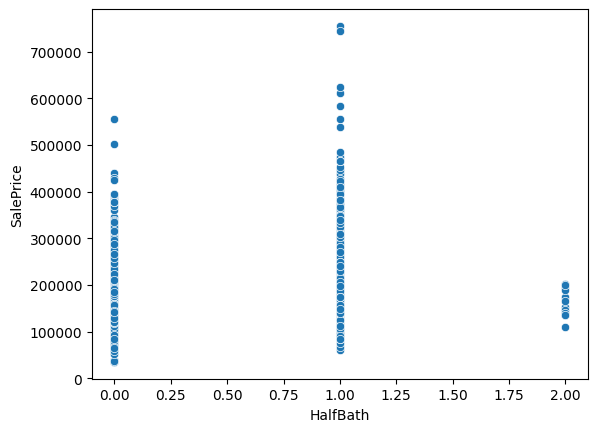

In [44]:
sns.scatterplot(x="HalfBath", y="SalePrice", data=train_df)

<Axes: xlabel='BedroomAbvGr', ylabel='SalePrice'>

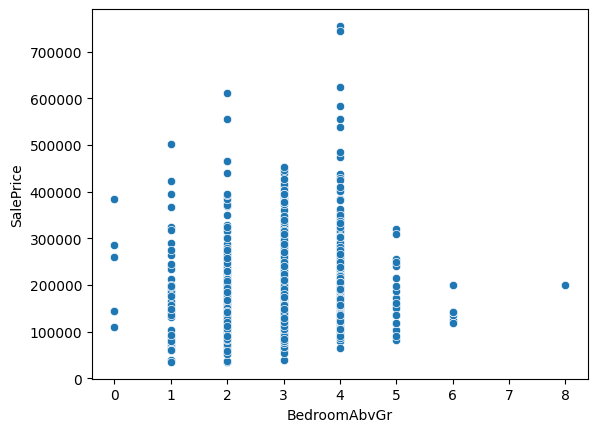

In [45]:
sns.scatterplot(x="BedroomAbvGr", y="SalePrice", data=train_df)

In [46]:
train_df.query("BedroomAbvGr == 8")
#635

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Reg,Bnk,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Abnorml,200000


<Axes: xlabel='KitchenAbvGr', ylabel='SalePrice'>

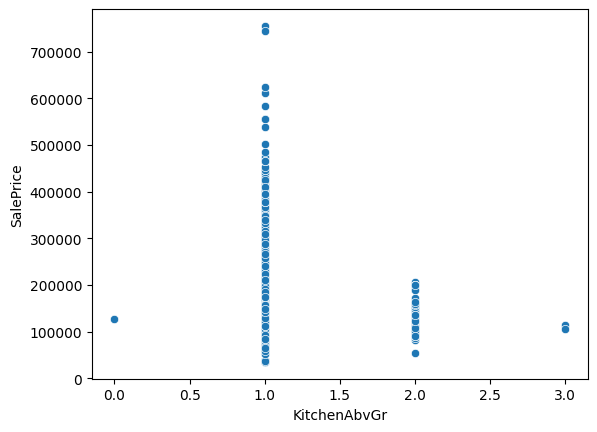

In [47]:
sns.scatterplot(x="KitchenAbvGr", y="SalePrice", data=train_df)

In [48]:
train_df.query("KitchenAbvGr == 3")
#48, 809

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,Reg,Lvl,AllPub,Inside,...,102,0,0,0,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,11,2009,WD,Normal,106000


<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

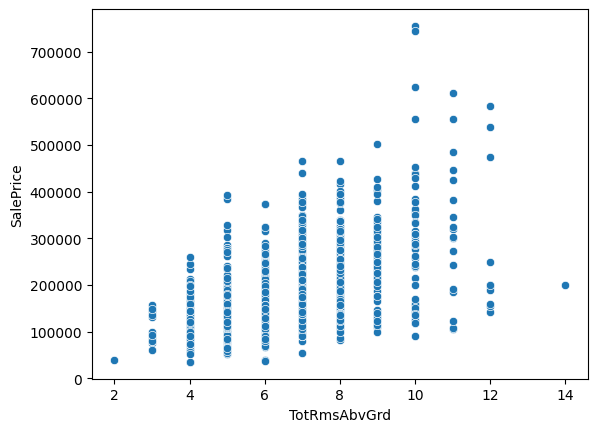

In [49]:
sns.scatterplot(x="TotRmsAbvGrd", y="SalePrice", data=train_df)

In [50]:
train_df.query("TotRmsAbvGrd == 14")
#635

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Reg,Bnk,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Abnorml,200000


<Axes: xlabel='Fireplaces', ylabel='SalePrice'>

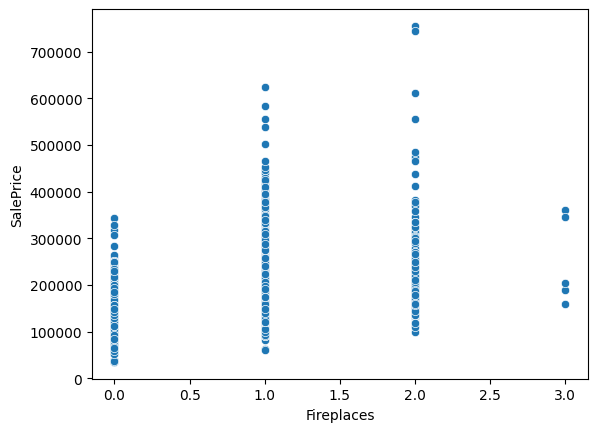

In [51]:
sns.scatterplot(x="Fireplaces", y="SalePrice", data=train_df)

<Axes: xlabel='GarageYrBlt', ylabel='SalePrice'>

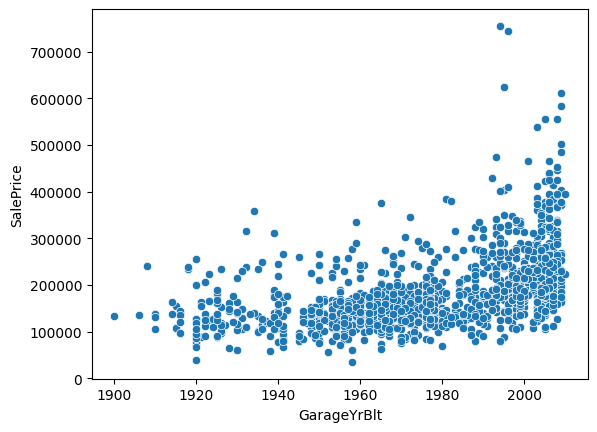

In [52]:
sns.scatterplot(x="GarageYrBlt", y="SalePrice", data=train_df)

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

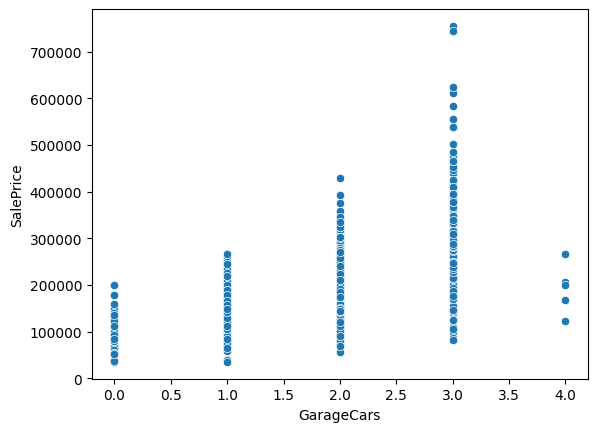

In [53]:
sns.scatterplot(x="GarageCars", y="SalePrice", data=train_df)

<Axes: xlabel='GarageArea', ylabel='SalePrice'>

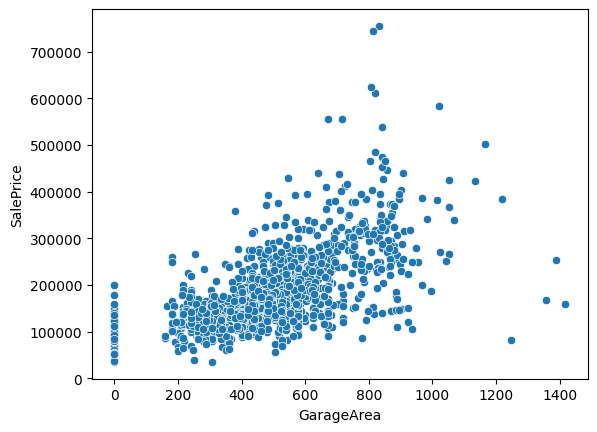

In [54]:
sns.scatterplot(x="GarageArea", y="SalePrice", data=train_df)

In [55]:
train_df.query("GarageArea > 1200 & SalePrice < 300000")
#581,1061,1190,1298

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2009,New,Partial,253293
1061,1062,30,C (all),120.0,18000,Grvl,Reg,Low,AllPub,Inside,...,0,0,0,0,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,NaN,32463,Pave,Reg,Low,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


<Axes: xlabel='WoodDeckSF', ylabel='SalePrice'>

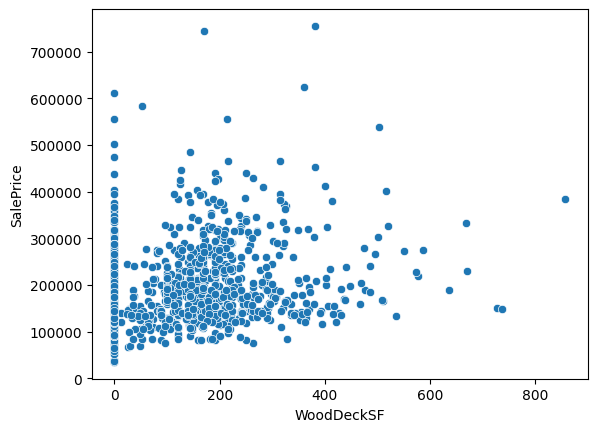

In [56]:
sns.scatterplot(x="WoodDeckSF", y="SalePrice", data=train_df)

<Axes: xlabel='OpenPorchSF', ylabel='SalePrice'>

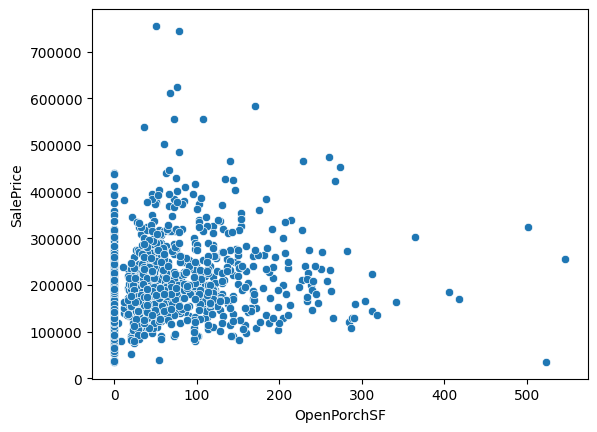

In [57]:
sns.scatterplot(x="OpenPorchSF", y="SalePrice", data=train_df)

In [58]:
train_df.query("OpenPorchSF > 500 & SalePrice < 100000")
#495

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,Reg,Lvl,AllPub,Inside,...,115,0,0,0,0,11,2009,WD,Abnorml,34900


<Axes: xlabel='EnclosedPorch', ylabel='SalePrice'>

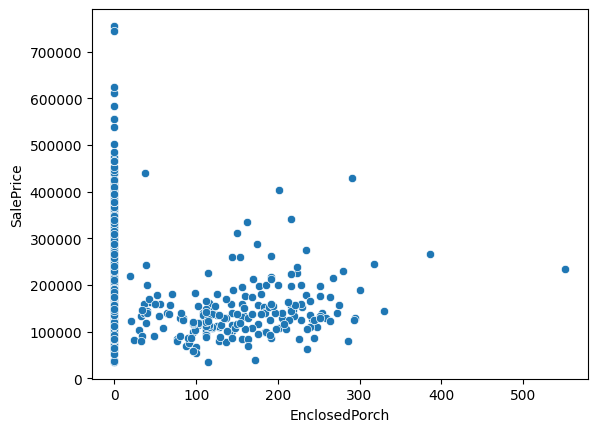

In [59]:
sns.scatterplot(x="EnclosedPorch", y="SalePrice", data=train_df)

In [60]:
train_df.query("EnclosedPorch > 500")
#197

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,Reg,Lvl,AllPub,Corner,...,552,0,0,512,0,3,2006,WD,Abnorml,235000


<Axes: xlabel='3SsnPorch', ylabel='SalePrice'>

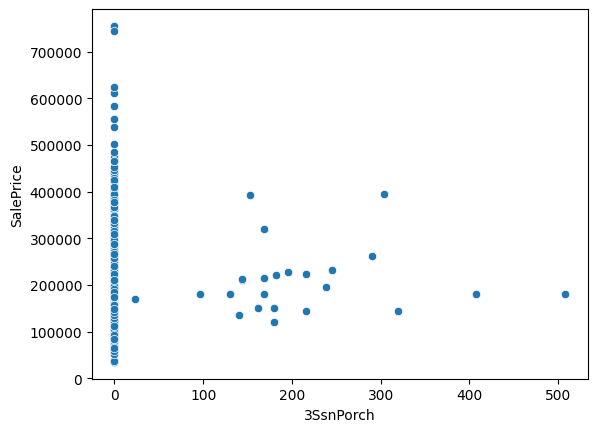

In [61]:
sns.scatterplot(x="3SsnPorch", y="SalePrice", data=train_df)

In [62]:
train_df[train_df["3SsnPorch"] > 500]
#205

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
205,206,20,RL,99.0,11851,Pave,Reg,Lvl,AllPub,Corner,...,0,508,0,0,0,5,2009,WD,Normal,180500


<Axes: xlabel='ScreenPorch', ylabel='SalePrice'>

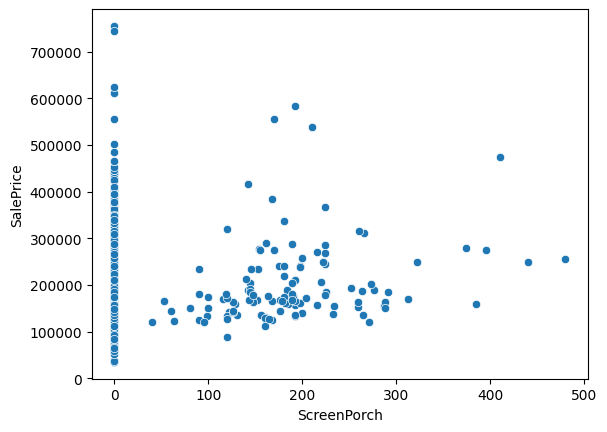

In [63]:
sns.scatterplot(x="ScreenPorch", y="SalePrice", data=train_df)

<Axes: xlabel='PoolArea', ylabel='SalePrice'>

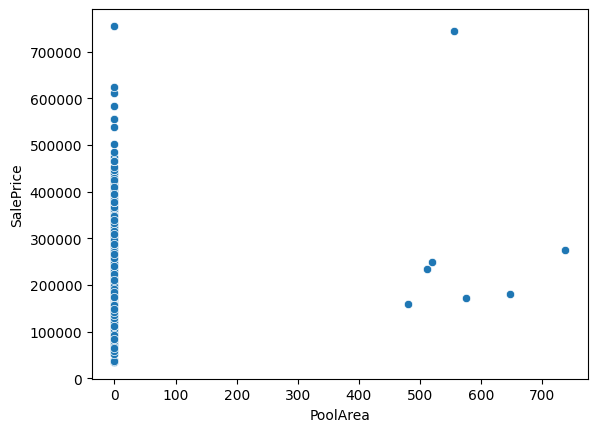

In [64]:
sns.scatterplot(x="PoolArea", y="SalePrice", data=train_df)

In [65]:
remove = list(set([934, 1298, 249, 313, 335, 706, 523, 1298, 378,691, 1182, 185,313, 1182, 297, 1298, 440, 1298, 185,523, 1298,738, 597, 954,635,48, 809,635,581,1061,1190,1298, 205, ]))
train_df.drop(remove, axis=0, inplace=True)

### Missing data

In [66]:
train_df.isnull().sum().sort_values(ascending=False).head(20)

,0
MasVnrType,861
FireplaceQu,683
LotFrontage,255
GarageFinish,77
GarageQual,77
GarageCond,77
GarageType,77
GarageYrBlt,77
BsmtExposure,38
BsmtFinType2,38


In [67]:
train_df["MasVnrType"].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [68]:
for df in [train_df, test_df]:
  df["MasVnrType"].fillna("No", inplace=True)

<ipython-input-68-e9611d977281>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MasVnrType"].fillna("No", inplace=True)


<Axes: xlabel='MasVnrType', ylabel='SalePrice'>

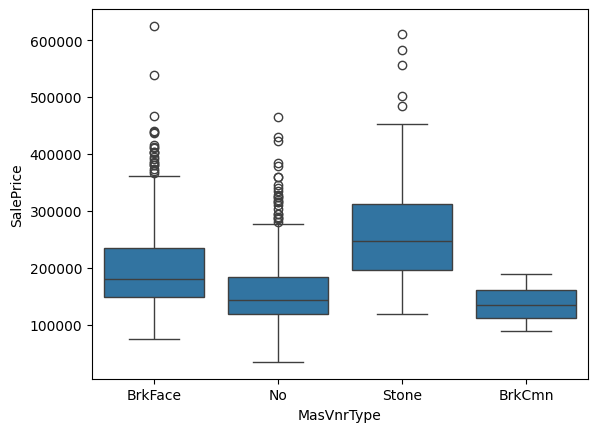

In [69]:
sns.boxplot(x="MasVnrType", y="SalePrice", data=train_df)

In [70]:
train_df["FireplaceQu"].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [71]:
for df in [train_df, test_df]:
  df["FireplaceQu"].fillna("No", inplace=True)

<ipython-input-71-e5c7574ed2c6>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["FireplaceQu"].fillna("No", inplace=True)


<Axes: xlabel='FireplaceQu', ylabel='SalePrice'>

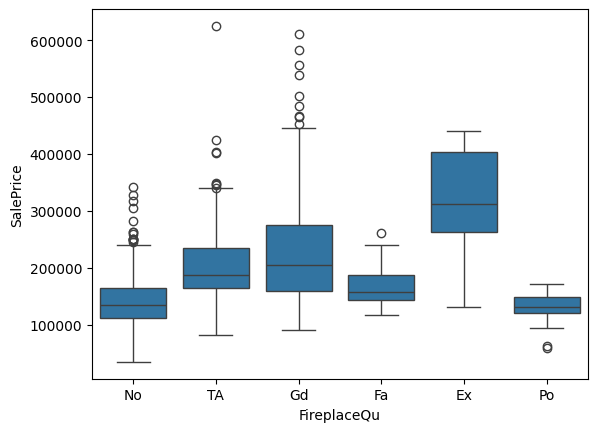

In [72]:
sns.boxplot(x="FireplaceQu", y="SalePrice", data=train_df)

In [73]:
train_df["LotFrontage"].unique()

array([ 65.,  80.,  68.,  60.,  84.,  85.,  75.,  nan,  51.,  50.,  70.,
        91.,  72.,  66., 101.,  57.,  44., 110.,  98.,  47., 108., 112.,
        74., 115.,  61.,  48.,  52., 100.,  24.,  89.,  63.,  76.,  81.,
        95.,  69.,  21.,  32.,  78., 121., 122.,  40., 105.,  73.,  77.,
        64.,  94.,  34.,  90.,  55.,  88.,  82.,  71., 120., 107.,  92.,
       134.,  62.,  86., 141.,  97.,  54.,  41.,  79., 174.,  67.,  83.,
        43., 103.,  93.,  30., 129., 140.,  35.,  37., 118.,  87., 116.,
       111.,  99.,  49.,  96.,  59.,  36.,  56., 102.,  58.,  38., 109.,
       130.,  53., 137.,  45., 106.,  42.,  39., 104., 144., 114., 128.,
       149., 168., 182., 138., 152., 124., 153.,  46.])

In [74]:
for df in [train_df, test_df]:
  df["LotFrontage"].fillna(0, inplace=True)

<ipython-input-74-185c32be7cf4>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LotFrontage"].fillna(0, inplace=True)


In [75]:
train_df["GarageFinish"].unique()

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

In [76]:
for df in [train_df, test_df]:
  df["GarageFinish"].fillna("No", inplace=True)

<ipython-input-76-6c454b3f83b3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GarageFinish"].fillna("No", inplace=True)


<Axes: xlabel='GarageFinish', ylabel='SalePrice'>

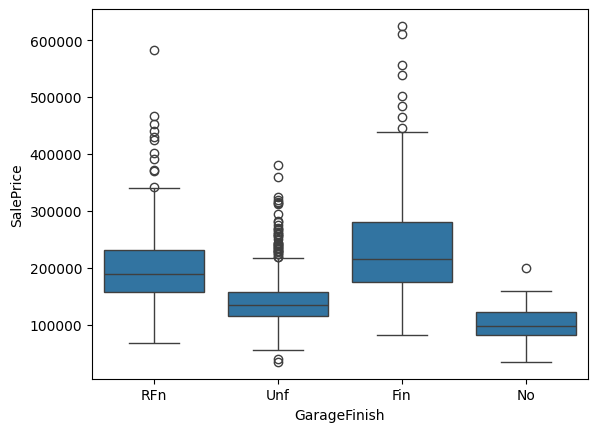

In [77]:
sns.boxplot(x="GarageFinish", y="SalePrice", data=train_df)

In [78]:
train_df["GarageQual"].unique()

array(['TA', 'Fa', 'Gd', nan, 'Po', 'Ex'], dtype=object)

In [79]:
for df in [train_df, test_df]:
  df["GarageQual"].fillna("No", inplace=True)

<ipython-input-79-c165f5f54d62>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GarageQual"].fillna("No", inplace=True)


<Axes: xlabel='GarageQual', ylabel='SalePrice'>

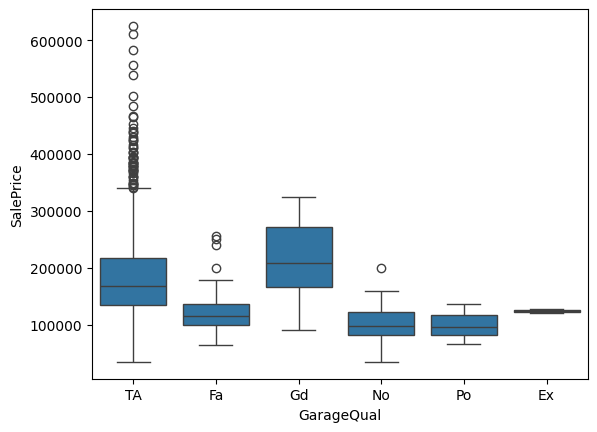

In [80]:
sns.boxplot(x="GarageQual", y="SalePrice", data=train_df)

In [81]:
train_df["GarageCond"].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

In [82]:
train_df["GarageCond"].fillna("No", inplace=True)

<ipython-input-82-b7e853de63e7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["GarageCond"].fillna("No", inplace=True)


<Axes: xlabel='GarageCond', ylabel='SalePrice'>

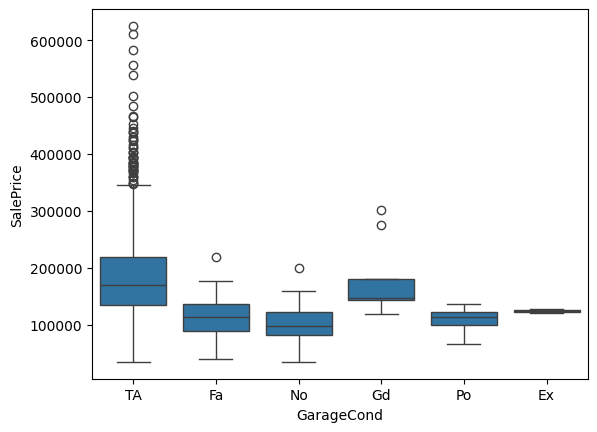

In [83]:
sns.boxplot(x="GarageCond", y="SalePrice", data=train_df)

In [84]:
train_df["GarageType"].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [85]:
train_df["GarageType"].fillna("No", inplace=True)

<ipython-input-85-61225ce9ba81>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["GarageType"].fillna("No", inplace=True)


<Axes: xlabel='GarageType', ylabel='SalePrice'>

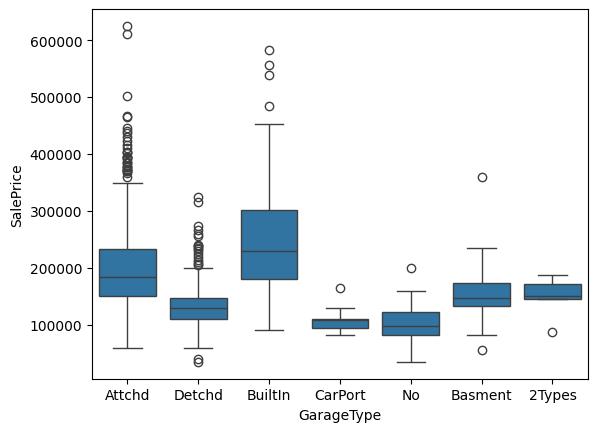

In [86]:
sns.boxplot(x="GarageType", y="SalePrice", data=train_df)

In [87]:
train_df["GarageYrBlt"].corr(train_df["YearBuilt"])

np.float64(0.8282888782633173)

In [88]:
train_df["BsmtExposure"].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [89]:
train_df["BsmtExposure"].fillna("No", inplace=True)

<ipython-input-89-87d29071af7f>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["BsmtExposure"].fillna("No", inplace=True)


<Axes: xlabel='BsmtExposure', ylabel='SalePrice'>

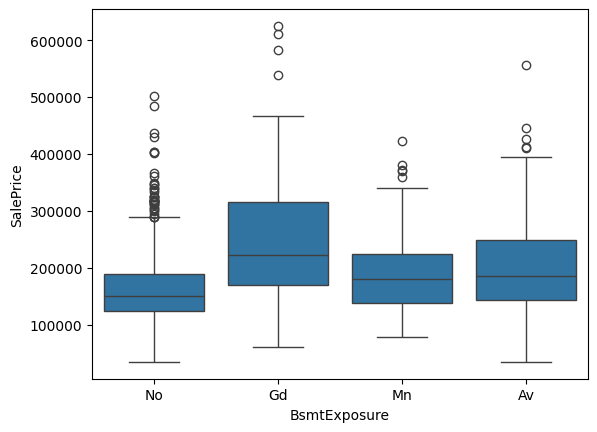

In [90]:
sns.boxplot(x="BsmtExposure", y="SalePrice", data=train_df)

In [91]:
train_df["BsmtFinType2"].unique()

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [92]:
train_df["BsmtFinType2"].fillna("Unf", inplace=True)

<ipython-input-92-5297b493ae4d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["BsmtFinType2"].fillna("Unf", inplace=True)


<Axes: xlabel='BsmtFinType2', ylabel='SalePrice'>

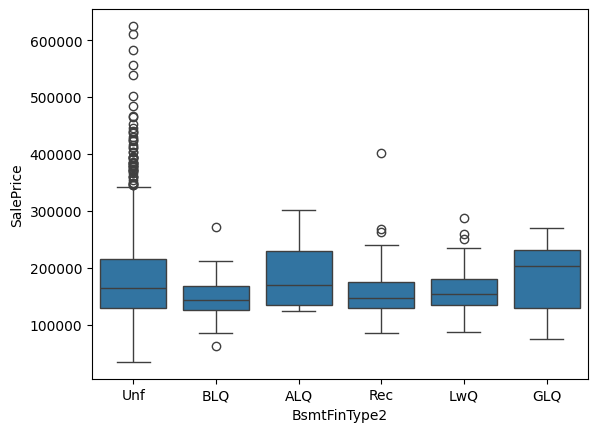

In [93]:
sns.boxplot(x="BsmtFinType2", y="SalePrice", data=train_df)

In [94]:
train_df["BsmtFinType1"].unique()

array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

In [95]:
train_df["BsmtFinType1"].fillna("Unf", inplace=True)

<ipython-input-95-0d6185766425>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["BsmtFinType1"].fillna("Unf", inplace=True)


<Axes: xlabel='BsmtFinType1', ylabel='SalePrice'>

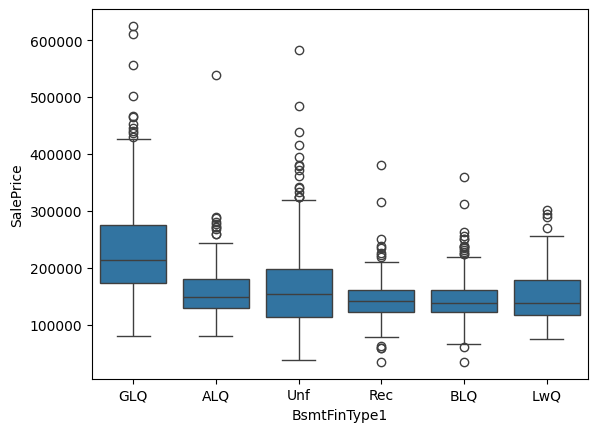

In [96]:
sns.boxplot(x="BsmtFinType1", y="SalePrice", data=train_df)

In [97]:
train_df["BsmtCond"].unique()

array(['TA', 'Gd', nan, 'Fa', 'Po'], dtype=object)

In [98]:
train_df["BsmtCond"].fillna("No", inplace=True)

<ipython-input-98-69ca453ae1fa>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["BsmtCond"].fillna("No", inplace=True)


<Axes: xlabel='BsmtCond', ylabel='SalePrice'>

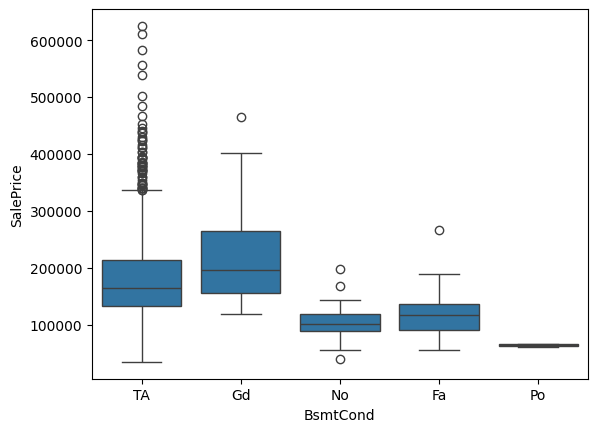

In [99]:
sns.boxplot(x="BsmtCond", y="SalePrice", data=train_df)

In [100]:
train_df["BsmtQual"].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [101]:
train_df["BsmtQual"].fillna("No", inplace=True)

<ipython-input-101-c5390a98f4b4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["BsmtQual"].fillna("No", inplace=True)


<Axes: xlabel='BsmtQual', ylabel='SalePrice'>

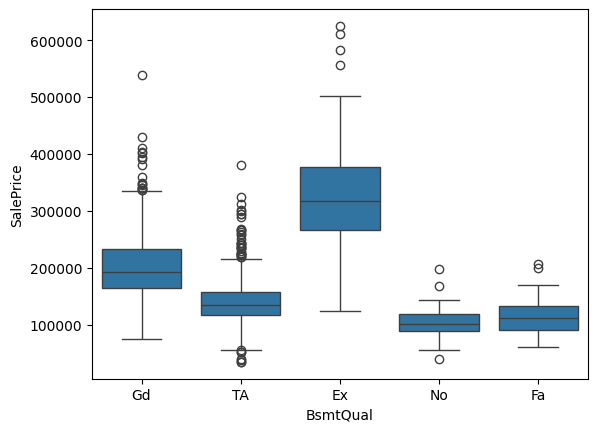

In [102]:
sns.boxplot(x="BsmtQual", y="SalePrice", data=train_df)

In [103]:
train_df["MasVnrArea"].fillna(0, inplace=True)

<ipython-input-103-e32ecceaa7f8>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["MasVnrArea"].fillna(0, inplace=True)


In [104]:
train_df["Electrical"].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [105]:
train_df["Electrical"].fillna("SBrkr", inplace=True)

<ipython-input-105-c771739325ad>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Electrical"].fillna("SBrkr", inplace=True)


In [106]:
remove_col = ["GarageYrBlt", "BsmtFinType2","GarageCond"]
for df in [train_df, test_df]:
  df.drop(remove_col, axis=1, inplace=True)

### Feature engineering

In [107]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
       'GarageQual', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3Ssn

In [108]:
for df in [train_df, test_df]:
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    df["TotalBath"] = df["BsmtFullBath"] + df["FullBath"] + 0.5 * (df["BsmtHalfBath"] + df["HalfBath"])
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["TotalArea"] = df["GrLivArea"] + df["TotalPorchSF"] + df["TotalBsmtSF"]
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

In [110]:
remove_col = ["YrSold", "YearBuilt", "YearRemodAdd", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "BsmtFullBath", "FullBath", "BsmtHalfBath", "HalfBath", "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "WoodDeckSF"]
for df in [train_df, test_df]:
  df.drop(remove_col, axis=1, inplace=True)

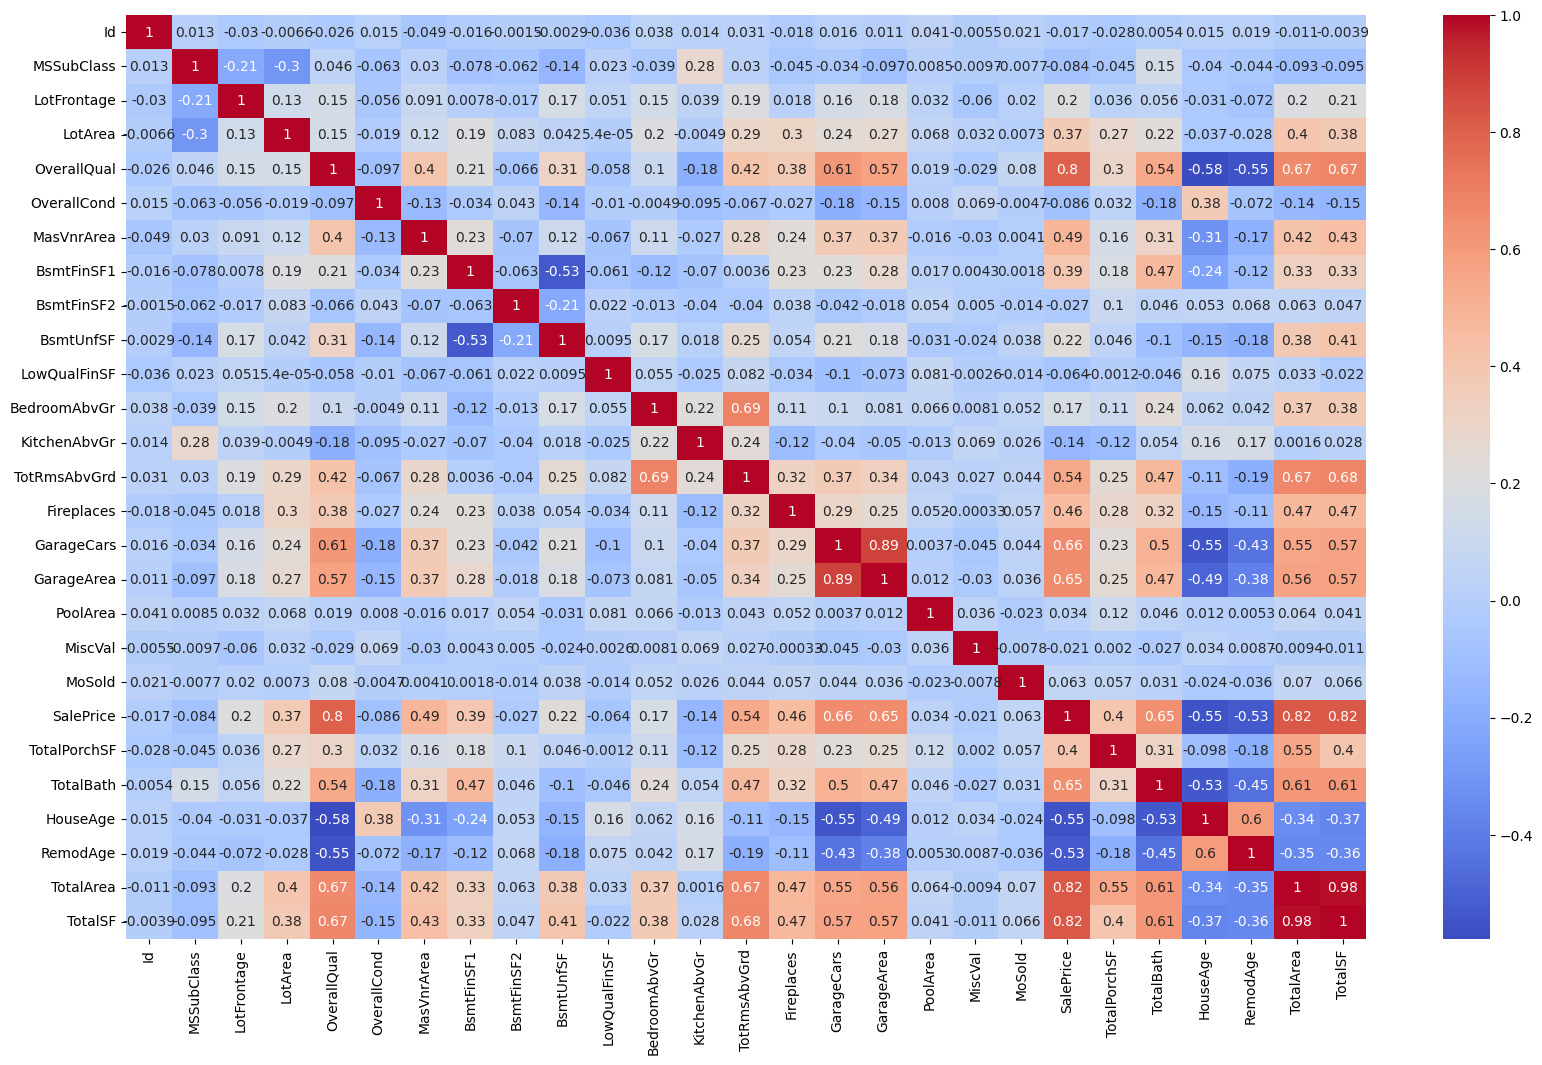

In [111]:
correlation_matrix = train_df.corr(numeric_only=True)
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

In [112]:
for df in [train_df, test_df]:
  df.drop(["GarageCars"], axis=1, inplace=True)
  df.drop(["TotalSF"], axis=1, inplace=True)

### Encoding

In [131]:
num_cols = train_df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop("SalePrice")

In [117]:
train_df.dtypes[train_df.dtypes=='object']

,0
MSZoning,object
Street,object
LotShape,object
LandContour,object
Utilities,object
LotConfig,object
LandSlope,object
Neighborhood,object
Condition1,object
Condition2,object


In [121]:
ode_cols = ["LotShape","LandContour","Utilities", "LandSlope", "BsmtQual", "BsmtCond",
            "BsmtExposure", "BsmtFinType1","ExterQual", "ExterCond", "HeatingQC", "CentralAir", "KitchenQual",
            "Functional", "FireplaceQu", "GarageFinish", "GarageQual", "PavedDrive"
            ]

In [122]:
ohe_cols = ["LotConfig", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
            "Exterior1st", "Exterior2nd", "MasVnrType","Foundation","Heating", "GarageType", "Electrical", "MSZoning",
            "SaleType", "SaleCondition", "Street"
            ]

In [140]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [141]:
ode_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

In [142]:
ohe_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
])

In [143]:
col_trans = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("ode", ode_pipeline, ode_cols),
    ("ohe", ohe_pipeline, ohe_cols)
])

In [144]:
pipeline = Pipeline([
    ("preprocessing", col_trans)
])

In [135]:
X, Y = train_df.drop("SalePrice", axis=1), train_df["SalePrice"]

In [145]:
X_preprocessed = pipeline.fit_transform(X)

In [172]:
Y = np.log1p(Y)

## Model building

In [173]:
x_train, x_test, y_train, y_test = train_test_split(X_preprocessed, Y, test_size=0.3, random_state=42)

In [175]:
parameter_grid = {
    "xgb":
    {
        "model": XGBRegressor(),
        "params": {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5, 7, 10],
            "subsample": [0.5, 0.7, 1.0]
        }
    },
    "svm" : {
        "model": SVR(),
        "params": {
            "kernel": ["linear", "rbf"],
            "C": [0.1, 1, 10, 100]
        }
    },
    "lasso": {
        "model": Lasso(),
        "params": {
            "alpha": [0.001, 0.01, 0.1, 1, 10]
        }
    },
    "ridge": {
        "model": Ridge(),
        "params": {
            "alpha": [0.001, 0.01, 0.1, 1, 10]
        }
    },
    "elasticnet": {
        "model": ElasticNet(),
        "params": {
            "alpha": [0.001, 0.01, 0.1, 1, 10]
        }
    },
    "randomforest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators": [100, 200,300],
            "max_depth": [3, 5, 7, 10],
            "min_samples_split": [2, 5]
        }
    },
    "linear": {
        "model": LinearRegression(),
        "params": {
        }
    }
}

In [176]:
res = []
for model_name, parameters in parameter_grid.items():
  grid = GridSearchCV(parameters["model"], parameters["params"], cv = 3, scoring="neg_root_mean_squared_error")
  grid.fit(x_train, y_train)
  res.append({
      "model": model_name,
      "best_params": grid.best_params_,
      "best_score": grid.best_score_
  })
res = pd.DataFrame(res)
res

,model,best_params,best_score
0,xgb,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",-0.116413
1,svm,"{'C': 0.1, 'kernel': 'linear'}",-0.111175
2,lasso,{'alpha': 0.001},-0.108907
3,ridge,{'alpha': 10},-0.108082
4,elasticnet,{'alpha': 0.001},-0.107161
5,randomforest,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",-0.131715
6,linear,{},-0.119985


## Result

Score: 0.12940 , Top 24%

In [160]:
test = pipeline.transform(test_df)

In [188]:
vt = VotingRegressor(estimators=[
    ("elasticnet" ,ElasticNet(**{'alpha': 0.01})),
    ("ridge", Ridge(**{'alpha': 10})),
    ("lasso", Lasso(**{'alpha': 0.001})),
    ("xgb", XGBRegressor(**{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.5}))
])
model = StackingRegressor(
    estimators=[
        ("xgb", XGBRegressor(**{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.5})),
        ("elasticnet" ,ElasticNet(**{'alpha': 0.01})),
        ("ridge", Ridge(**{'alpha': 10})),
        ("lasso", Lasso(**{'alpha': 0.001})),
        ("svm", SVR(**{'C': 0.1, 'kernel': 'linear'})),
        ("randomforest", RandomForestRegressor(**{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300})),
        ("linear", LinearRegression())
    ],
    final_estimator=vt,
    passthrough=True
)

In [189]:
model.fit(X_preprocessed, Y)

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                                                            importance_type=None,
                                                                            interaction_constraints=None,
                                                                            learning_rate=0.1,
                                                                            max_bin=None,
                                                                            max_cat_threshold=None,
                                                                            max_cat_to_onehot=None,
                                                                            max_delta_step=None,
                                                                            max_depth=3,
                                                                            max_leaves=None,
                                                                            min_child_weight=None,
                                                                            missing=nan,
                                                                            monotone_constraints=None,
                                                                            multi_strategy=None,
                                                                            n_estimators=200,
                                                                            n_jobs=None,
                                                                            num_parallel_tree=None,
                                                                            random_state=None, ...))]),
                  passthrough=True)

In [190]:
y_ans = model.predict(test)
ans = pd.DataFrame({
    "Id": pd.read_csv("test.csv")["Id"],
    "SalePrice": np.exp(y_ans)
})
ans.to_csv("submission.csv", index=False)